### Edges
Edges represent sharp changes in intensity (or color) in a image ,These changes oftern correspond to object boundaries,textures,or other key features

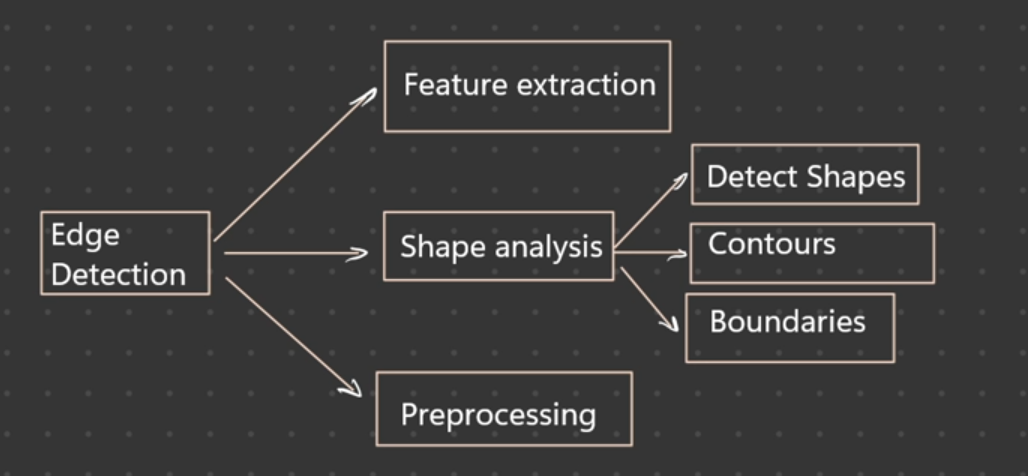

Filters

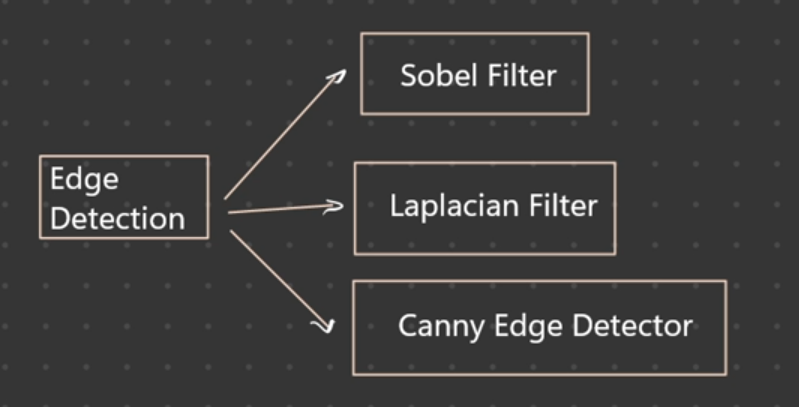

### 1. Sobel Operator
The Sobel operator computes the gradient of the image intensity at each point, giving the direction of the largest possible increase from light to dark and the rate of change in that direction. It uses two 3x3 convolution kernels to calculate the gradient in the horizontal and vertical directions.

Working of the Sobel Operator

Compute Horizontal and Vertical Gradients: Apply the Sobel kernels to the image to obtain the gradients in the x (horizontal) and y (vertical) directions.


**Sobel Kernel (Horizontal):**

\begin{bmatrix}
-1 & -2 & -1 \\
0 & 0 & 0 \\
1 & 2 & 1
\end{bmatrix}

**Sobel Kernel (Vertical):**


\begin{bmatrix}
-1 & 0 & 1 \\
-2 & 0 & 2 \\
-1 & 0 & 1
\end{bmatrix}


Calculate Gradient Magnitude and Direction: Use the gradients to compute the magnitude and direction of the edge at each pixel.

$$
\text{Gradient Magnitude} = \sqrt{G_x^2 + G_y^2}
$$


$$
\text{Gradient Direction} = \arctan\left(\frac{G_y}{G_x}\right)
$$

Where 
G
x
G 
x
​
 ​ and 
G
y
G 
y
​
 ​ are the gradients in the horizontal and vertical directions, respectively.

In [1]:
import cv2
import matplotlib.pyplot as plt

### The Laplacian Operator
The Laplacian Operator achieves a sharpening effect by enhancing the grayscale contrast of the image. As a second-order differential operator, it enhances areas with sudden grayscale changes in the image and weakens areas with slow grayscale changes. But the processed image loses the direction information of the edges and enhances the noise.

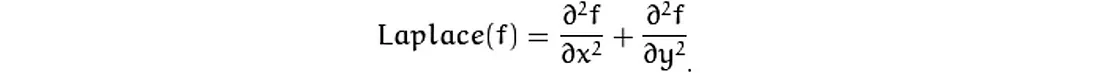

Laplace detects the edges by finding regions of rapid intensity change.Unlike sobel,it combines x and y-direction derivative in a single operation

The Laplacian kernel below is a discrete approximation of this continuous mathematical derivative

**Laplacian Kernel (4-neighbor):**
$$
\begin{bmatrix}
0 & -1 & 0 \\
-1 & 4 & -1 \\
0 & -1 & 0
\end{bmatrix}
$$

**Laplacian Kernel (8-neighbor):**
$$
\begin{bmatrix}
-1 & -1 & -1 \\
-1 & 8 & -1 \\
-1 & -1 & -1
\end{bmatrix}
$$


### Canny Edge detection Method
Steps in the Canny Edge Detection Algorithm
1. Noise Reduction (Gaussian Blur)

Why? Images often contain noise which can create false edges.

How? Apply a Gaussian filter (a type of smoothing filter) to blur the image and reduce noise.

Gaussian Filter:

$$
G(x, y) = \frac{1}{2\pi\sigma^2} \cdot e^{-\frac{x^2 + y^2}{2\sigma^2}}
$$

2. Gradient Calculation
Why? To detect the intensity change in the image.

How? Compute the gradient magnitude and direction using edge-detecting operators like Sobel.

Gradient Magnitude:

$$
G = \sqrt{G_x^2 + G_y^2}
$$

Gradient Direction:

$$
\theta = \arctan\left(\frac{G_y}{G_x}\right)
$$

3. Non-Maximum Suppression (NMS)
Why? To thin the edges and keep only the local maxima.

How? Traverse the image and suppress any pixel value that is not considered to be part of an edge (not a local maximum in the gradient direction).

4. Double Thresholding
Why? To classify edges as strong, weak, or irrelevant.

High Threshold: Pixels with gradient magnitude above this are considered strong edges.

Low Threshold: Pixels between the high and low are weak edges.

Pixels below the low threshold are discarded.

5. Edge Tracking by Hysteresis
Why? To determine final edges.

Strong edges are retained.

Weak edges are kept only if they are connected to strong edges (to avoid detecting noise as edges).


In [4]:
image = cv2.imread("asserts/giraffe-Kenya.png",cv2.IMREAD_GRAYSCALE)

# sobel edge detector
sobel_x = cv2.Sobel(image,cv2.CV_64F,1,0,ksize=3)
sobel_y = cv2.Sobel(image,cv2.CV_64F,0,1,ksize=3)
Sobel_combined = cv2.magnitude(sobel_x,sobel_y)

# laplacian
laplacian = cv2.Laplacian(image,cv2.CV_64F,ksize=3)
laplacian_abs = cv2.convertScaleAbs(laplacian)

# canny
canny_edges = cv2.Canny(image,180,200)

In [3]:
laplacian_abs

array([[ 80,  80,  80, ...,  36,  24,  24],
       [ 20,  72,  72, ...,   4,  24,  24],
       [148,  10,  10, ...,  24,  28,  28],
       ...,
       [ 64,  48,  64, ...,   6,  20,  88],
       [ 16, 120, 100, ...,  14,   8, 112],
       [160,   4,  20, ...,  40,   0, 128]],
      shape=(1600, 1067), dtype=uint8)

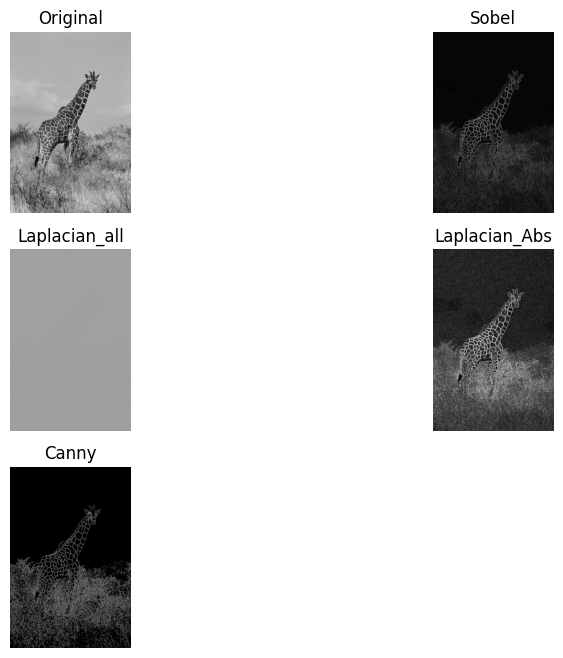

In [5]:
titles = ['Original','Sobel','Laplacian_all','Laplacian_Abs','Canny']
image = [image,Sobel_combined,laplacian,laplacian_abs,canny_edges]

plt.figure(figsize=(10,8))
for i in range(len(titles)):
    plt.subplot(3,2,i+1)
    plt.imshow(image[i],cmap='grey')
    plt.title(titles[i])
    plt.axis('off')
plt.show()